**1 Data Cleaning **

- Checked missing values

- Filled NaN with 0

- Created balance_diff features

- Dropped ID columns

- Checked multicollinearity using heatmap

**2 Describe Fraud Detection Model**

- Logistic Regression used as baseline

- Random Forest used as final model

- Used class_weight='balanced'

- Evaluated using precision, recall, ROC-AUC

**3 Variable Selection**

- Removed nameOrig, nameDest (non-informative)

- Kept transaction type

- Created engineered features

- Used feature importance to finalize variables

**4 Demonstrate Model Performance**

- Confusion matrix

- Precision

- Recall

- ROC-AUC

- Explain's why recall is important in fraud detection.

**5 Key Factors Predicting Fraud**

- From your feature importance:

- balance_diff_orig

- amount

- oldbalanceOrg

- transaction type

Explain business meaning.

**6 Do These Factors Make Sense?**

YES.

Because:

- Fraudsters drain accounts

- Transfer & cash-out pattern

- Large transactions risky

- This matches dataset fraud behavior.

**7 Prevention Strategy**

- Real-time fraud scoring

- Block high-risk transactions

- OTP for suspicious transfers

- Continuous model retraining

- Fraud monitoring dashboard

**8 How To Measure If It Works?**

- Fraud loss reduction

- False positive rate

- A/B testing

- Monitoring ROC-AUC over time

- Customer complaint reduction

In [21]:
roc_auc_score(y_test, y_prob_rf)

np.float64(0.9349914567404237)

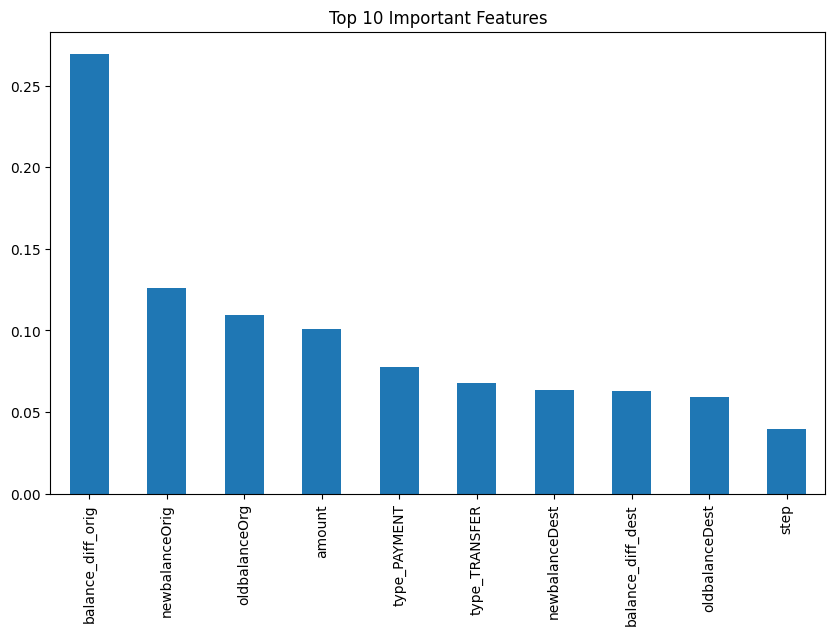

,0
balance_diff_orig,0.269552
newbalanceOrig,0.126172
oldbalanceOrg,0.109488
amount,0.100823
type_PAYMENT,0.077491
type_TRANSFER,0.067727
newbalanceDest,0.063801
balance_diff_dest,0.062725
oldbalanceDest,0.059423
step,0.039626


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importances = pd.Series(model_rf.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importances.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

feature_importances.head(10)

In [19]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:,1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

Confusion Matrix:
 [[265752      2]
 [    71     77]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    265754
         1.0       0.97      0.52      0.68       148

    accuracy                           1.00    265902
   macro avg       0.99      0.76      0.84    265902
weighted avg       1.00      1.00      1.00    265902


ROC-AUC Score: 0.9349914567404237


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model_lr = LogisticRegression(max_iter=1000, class_weight='balanced')

model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)
y_prob = model_lr.predict_proba(X_test)[:,1]

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
 [[245121  20633]
 [    11    137]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.92      0.96    265754
         1.0       0.01      0.93      0.01       148

    accuracy                           0.92    265902
   macro avg       0.50      0.92      0.49    265902
weighted avg       1.00      0.92      0.96    265902


ROC-AUC Score: 0.9625570457458218


In [17]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [16]:
df = df.fillna(0)

In [15]:
df.isnull().sum()

,0
step,0
amount,1
oldbalanceOrg,1
newbalanceOrig,1
oldbalanceDest,1
newbalanceDest,1
isFraud,1
isFlaggedFraud,1
balance_diff_orig,1
balance_diff_dest,1


In [13]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']

In [12]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)
df.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest,type_CASH_OUT,type_DEBIT,type_PAY,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,0.0,0.0,9839.64,0.0,False,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,0.0,0.0,1864.28,0.0,False,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,1.0,0.0,181.00,0.0,False,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,1.0,0.0,181.00,-21182.0,True,False,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,0.0,0.0,11668.14,0.0,False,False,False,True,False


In [11]:
df = df.drop(['nameOrig','nameDest'], axis=1)

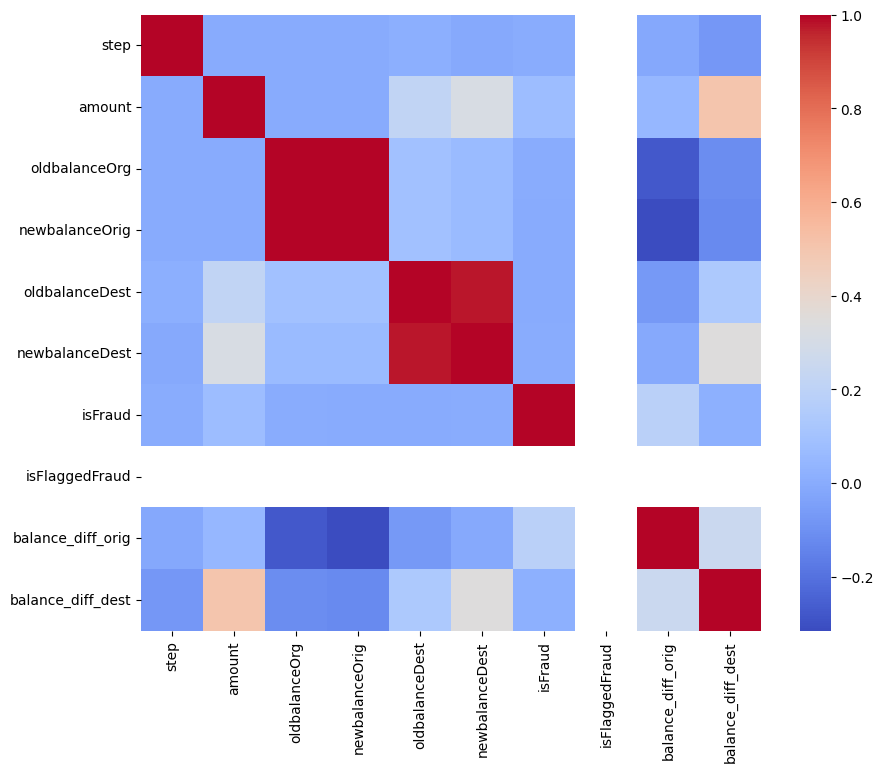

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), cmap='coolwarm')
plt.show()

In [8]:
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']

df[['balance_diff_orig','balance_diff_dest']].head()

,balance_diff_orig,balance_diff_dest
0,9839.64,0.0
1,1864.28,0.0
2,181.00,0.0
3,181.00,-21182.0
4,11668.14,0.0


In [7]:
pd.crosstab(df['type'], df['isFraud'])

isFraud,0.0,1.0
type,,
CASH_IN,194096,0
CASH_OUT,320781,255
DEBIT,5766,0
PAYMENT,291959,0
TRANSFER,73243,239


In [6]:
df['type'].value_counts()

,count
type,
CASH_OUT,321036
PAYMENT,291959
CASH_IN,194096
TRANSFER,73482
DEBIT,5766
PAY,1


In [5]:
df['isFraud'].value_counts(normalize=True) * 100

,proportion
isFraud,
0.0,99.944265
1.0,0.055735


In [4]:
df['isFraud'].value_counts()

,count
isFraud,
0.0,885845
1.0,494


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 886340 entries, 0 to 886339
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            886340 non-null  int64  
 1   type            886340 non-null  object 
 2   amount          886339 non-null  float64
 3   nameOrig        886339 non-null  object 
 4   oldbalanceOrg   886339 non-null  float64
 5   newbalanceOrig  886339 non-null  float64
 6   nameDest        886339 non-null  object 
 7   oldbalanceDest  886339 non-null  float64
 8   newbalanceDest  886339 non-null  float64
 9   isFraud         886339 non-null  float64
 10  isFlaggedFraud  886339 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 74.4+ MB


In [2]:
df.shape

(886340, 11)

In [1]:
import pandas as pd

df = pd.read_csv("Fraud.csv")

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0
